In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_simpson, cumulative_trapezoid

from Triangle.GW import GeneralTDIResponse, FastMichelsonTDIResponse
from Triangle.Constants import * 
from Triangle.Orbit import * 
from Triangle.TDI import TDIStringManipulation, AETfromXYZ
from Triangle.Glitch import * 

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


no cupy 


In [2]:
class Glitch:
    short_glitch_kwargs = dict(dv=2.2e-12, tau1=10.0, tau2=11.0)
    long_glitch_kwargs = dict(dv=1.18e-12, tau1=5661.65, tau2=5661.71)

    def __init__(self, fsample=1.0):
        self.fsample = fsample

    def LPF_legacy_glitch_model(self, t, dv, tau1, tau2, t0=0):
        """
        LPF glitch model in the unit of acceleration [m/s2]
        """
        res = np.zeros_like(t)
        inds = np.where(t >= t0)[0]
        t = t[inds]
        res[inds] = dv / (tau1 - tau2) * (np.exp(-(t - t0) / tau1) - np.exp(-(t - t0) / tau2)) * np.heaviside(t - t0, 1)
        # res = dv / (tau1 - tau2) * (np.exp(-(t - t0) / tau1) - np.exp(-(t - t0) / tau2)) 
        
        return res

    def acc2ffd(self, data):
        """
        convert acceleration to fractional frequency difference, which can be then used as Interferometer.BasicNoise["acc_noise"]
        """
        return cumulative_trapezoid(np.insert(data, 0, 0), dx=1 / self.fsample) / C

In [3]:
class GlitchInGeneralTDI(GeneralTDIResponse): 
    def __init__(self, orbit, TDIstring, tcb_times):
        
        Pstring=TDIstring
        use_gpu=False 
        drop_points=0,
        linear_interp=False 
        return_eta=False
        
        super().__init__(orbit, Pstring, tcb_times, use_gpu, drop_points, linear_interp, return_eta)
        
        self.dt = tcb_times[1] - tcb_times[0]
        self.dij = dict()
        for key in MOSA_labels: 
            self.dij[key] = self.orbit_object.LTTfunctions()[key](self.tcb_times)
        
        
    def generate_test_mass_glitch(self, glitch_generator, parameters, location="12", start_time_index=None, end_time_index=None, drop_points=None): 
        """ 
        Parameters: 
            glitch_generator: a function that takes time and parameter dictionary as inputs, and returns a time series of test-mass acceleration glitch
            location: the index of test mass where glitch occurs, should be one of ["12", "23", "31", "21", "32", "13"]
            since glitch is transient, one can always use star_time_index and end_time_index to specify the time duration of it (within self.tcb_times)
        Return: 
            a time series of glitch in the fractional frequency difference unit, can be inserted to the full time series of some TDI observable as: 
            TDI[start_time_index : end_time_index+1] += output of this function
        """
        if location not in MOSA_labels: 
            raise ValueError('Invalid glitch location. The value should be one of ["12", "23", "31", "21", "32", "13"].')
        if start_time_index is None: 
            start_time_index = 0
        if end_time_index is None: 
            end_time_index = len(self.tcb_times) - 1 
            
        # glitch at TM_ij affects eta_ij and eta_ji:
        # eta_ij += delta_ij 
        # eta_ji += D_ji delta_ij 
        ij = location
        ji = ij[1]+ij[0]
        print("ij =", ij, "ji=", ji)
        
        glitch_time_in_TDI = self.tcb_times[start_time_index:end_time_index+1]
        acc_glitch_in_TDI = np.zeros_like(glitch_time_in_TDI)
        
        if self.Ndelay_dict[ij] > 0:
            print("has contribution from", ij)
            for Idelay in range(self.Ndelay_dict[ij]): 
                delayed_time = glitch_time_in_TDI - self.delay_dict[ij][Idelay][start_time_index:end_time_index+1]
                acc_glitch_in_TDI += self.delay_factor_dict[ij][Idelay] * glitch_generator(delayed_time, parameters)
                
        if self.Ndelay_dict[ji] > 0: 
            print("has contribution from", ji)
            for Idelay in range(self.Ndelay_dict[ji]): 
                delayed_time = glitch_time_in_TDI - self.delay_dict[ji][Idelay][start_time_index:end_time_index+1] - self.dij[ji][start_time_index:end_time_index+1]
                acc_glitch_in_TDI += self.delay_factor_dict[ji][Idelay] * glitch_generator(delayed_time, parameters)
        
        # assume time delay and unit conversion are commutative since the delays vary slowly compared to the transient time scale of glitches 
        # ffd_glitch_in_TDI = cumulative_trapezoid(y=np.insert(acc_glitch_in_TDI, 0, 0), dx=self.dt) / C 
        ffd_glitch_in_TDI = cumulative_simpson(y=np.insert(acc_glitch_in_TDI, 0, 0), dx=self.dt) / C 
        
        if drop_points is not None:
            ffd_glitch_in_TDI[:drop_points] = 0. 
            ffd_glitch_in_TDI[-drop_points:] = 0. 
        
        return ffd_glitch_in_TDI 

    

### Set times 

In [4]:
Tobs = YEAR / 10.
dt = 3.

tcb_times = np.arange(int(Tobs/dt)) * dt 
Tobs = len(tcb_times) * dt 

glitch_time = 10 * DAY 
start_time = glitch_time - 3. * DAY 
end_time = glitch_time + 3. * DAY 
glitch_time_idx = np.where((tcb_times>=start_time)&(tcb_times<=end_time))[0]
start_time_idx = glitch_time_idx[0]
end_time_idx = glitch_time_idx[-1]
glitch_times = tcb_times[start_time_idx:end_time_idx+1]

### Set glitch model 

In [5]:
glitch = Glitch(fsample=1./dt)

# this wrapper will be used by the glitch-in-TDI generator 
def LPF_glitch_wrapper(time, parameters): 
    return glitch.LPF_legacy_glitch_model(t=time, **parameters)

# an example for the glitch parameter dictionary 
long_glitch_parameters = glitch.long_glitch_kwargs.copy() 
long_glitch_parameters["t0"] = glitch_time

short_glitch_parameters = glitch.short_glitch_kwargs.copy() 
short_glitch_parameters["t0"] = glitch_time

long_glitch_parameters, short_glitch_parameters

({'dv': 1.18e-12, 'tau1': 5661.65, 'tau2': 5661.71, 't0': 864000.0},
 {'dv': 2.2e-12, 'tau1': 10.0, 'tau2': 11.0, 't0': 864000.0})

Text(0, 0.5, 'Acceleration $({\\rm m}/{\\rm s}^2)$')

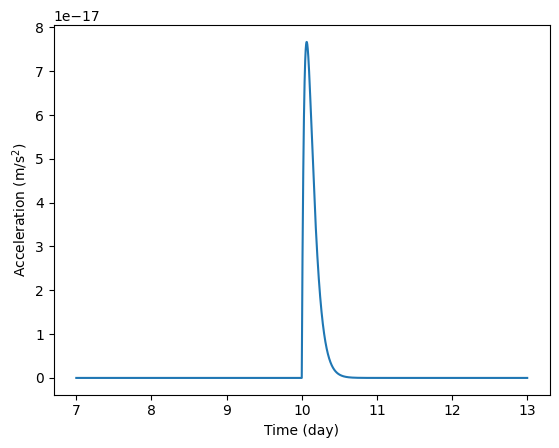

In [6]:
test_glitch_acc = LPF_glitch_wrapper(glitch_times, long_glitch_parameters)
plt.plot(glitch_times/DAY, test_glitch_acc)

plt.xlabel("Time (day)")
plt.ylabel("Acceleration "+r'$({\rm m}/{\rm s}^2)$')

### Generate the contribution of glitch to TDI
This takes a while, but it only need to be initialized ONCE.   
If AET channels are desired, generating XYZ separately and combining into AET is a relatively efficient way. 

In [7]:
orbit = Orbit(OrbitDir="../OrbitData/MicroSateOrbitEclipticTCB")

X2_string = GeneralTDIResponse.X2_strings
Y2_string = TDIStringManipulation.TDIStringCyc(X2_string)
Z2_string = TDIStringManipulation.TDIStringCyc(Y2_string)

# initialize ONLY ONCE 
X_glitch_generator = GlitchInGeneralTDI(
    orbit=orbit, 
    TDIstring=X2_string, 
    tcb_times=tcb_times, # this is the time series of full data, the duration of glitch will be specified during generation 
)

In [8]:
glitch_in_X_from_12 = X_glitch_generator.generate_test_mass_glitch(
    glitch_generator=LPF_glitch_wrapper, 
    parameters=long_glitch_parameters, 
    location="12", # test mass 12 
    start_time_index=start_time_idx, 
    end_time_index=end_time_idx, 
)

glitch_in_X_from_21 = X_glitch_generator.generate_test_mass_glitch(
    glitch_generator=LPF_glitch_wrapper, 
    parameters=long_glitch_parameters, 
    location="21", 
    start_time_index=start_time_idx, 
    end_time_index=end_time_idx, 
)

glitch_in_X_from_23 = X_glitch_generator.generate_test_mass_glitch(
    glitch_generator=LPF_glitch_wrapper, 
    parameters=long_glitch_parameters, 
    location="23", 
    start_time_index=start_time_idx, 
    end_time_index=end_time_idx, 
)

glitch_in_X_from_32 = X_glitch_generator.generate_test_mass_glitch(
    glitch_generator=LPF_glitch_wrapper, 
    parameters=long_glitch_parameters, 
    location="32", 
    start_time_index=start_time_idx, 
    end_time_index=end_time_idx, 
)

glitch_in_X_from_31 = X_glitch_generator.generate_test_mass_glitch(
    glitch_generator=LPF_glitch_wrapper, 
    parameters=long_glitch_parameters, 
    location="31", 
    start_time_index=start_time_idx, 
    end_time_index=end_time_idx, 
)

glitch_in_X_from_13 = X_glitch_generator.generate_test_mass_glitch(
    glitch_generator=LPF_glitch_wrapper, 
    parameters=long_glitch_parameters, 
    location="13", 
    start_time_index=start_time_idx, 
    end_time_index=end_time_idx, 
)

ij = 12 ji= 21
has contribution from 12
has contribution from 21
ij = 21 ji= 12
has contribution from 21
has contribution from 12
ij = 23 ji= 32
ij = 32 ji= 23
ij = 31 ji= 13
has contribution from 31
has contribution from 13
ij = 13 ji= 31
has contribution from 13
has contribution from 31


(9.995, 10.005)

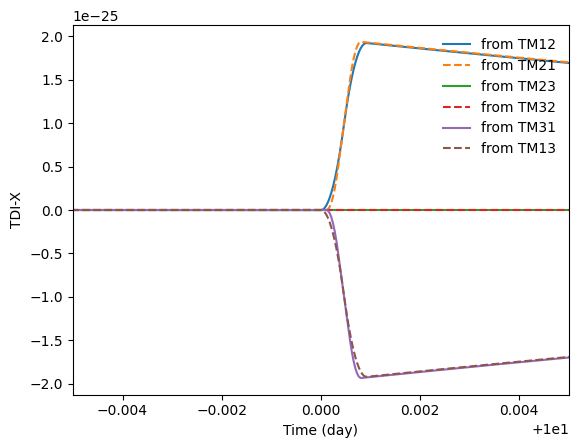

In [9]:
plt.plot(glitch_times/DAY, glitch_in_X_from_12, label="from TM12")
plt.plot(glitch_times/DAY, glitch_in_X_from_21, label="from TM21", linestyle="--")
plt.plot(glitch_times/DAY, glitch_in_X_from_23, label="from TM23")
plt.plot(glitch_times/DAY, glitch_in_X_from_32, label="from TM32", linestyle="--")
plt.plot(glitch_times/DAY, glitch_in_X_from_31, label="from TM31")
plt.plot(glitch_times/DAY, glitch_in_X_from_13, label="from TM13", linestyle="--")
plt.xlabel("Time (day)")
plt.ylabel("TDI-X")
plt.legend(loc="upper right", frameon=False)
plt.xlim(9.995, 10.005)
# plt.xlim(29.999, 30.003)

In [10]:
Y_glitch_generator = GlitchInGeneralTDI(
    orbit=orbit, 
    TDIstring=Y2_string, 
    tcb_times=tcb_times, # this is the time series of full data, the duration of glitch will be specified during generation 
)

Z_glitch_generator = GlitchInGeneralTDI(
    orbit=orbit, 
    TDIstring=Z2_string, 
    tcb_times=tcb_times, # this is the time series of full data, the duration of glitch will be specified during generation 
)

In [11]:
glitch_in_Y_from_12 = Y_glitch_generator.generate_test_mass_glitch(
    glitch_generator=LPF_glitch_wrapper, 
    parameters=long_glitch_parameters, 
    location="12", # test mass 12 
    start_time_index=start_time_idx, 
    end_time_index=end_time_idx, 
)

glitch_in_Z_from_12 = Z_glitch_generator.generate_test_mass_glitch(
    glitch_generator=LPF_glitch_wrapper, 
    parameters=long_glitch_parameters, 
    location="12", # test mass 12 
    start_time_index=start_time_idx, 
    end_time_index=end_time_idx, 
)

glitch_in_A_from_12, glitch_in_E_from_12, glitch_in_T_from_12 = AETfromXYZ(glitch_in_X_from_12, glitch_in_Y_from_12, glitch_in_Z_from_12)

ij = 12 ji= 21
has contribution from 12
has contribution from 21
ij = 12 ji= 21


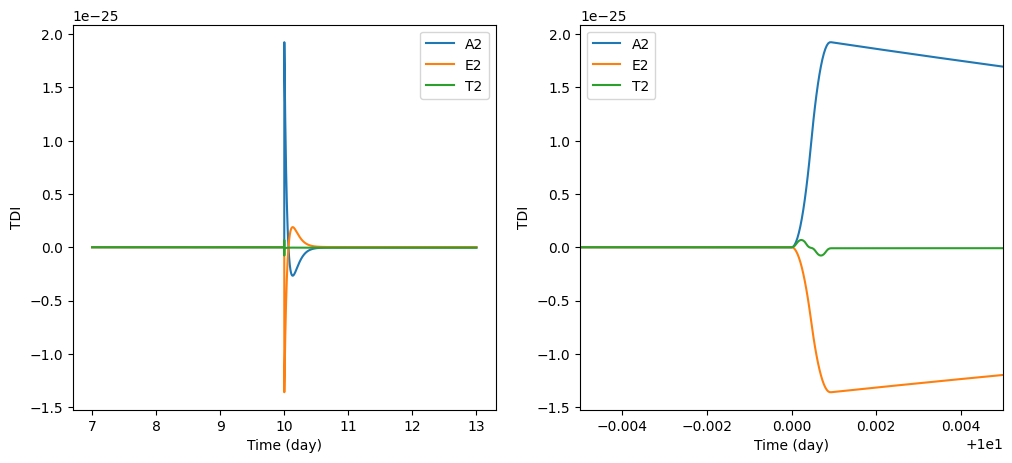

In [14]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(glitch_times/DAY, glitch_in_X_from_12, label="A2")
plt.plot(glitch_times/DAY, glitch_in_A_from_12, label="E2")
plt.plot(glitch_times/DAY, glitch_in_T_from_12, label="T2")
plt.xlabel("Time (day)")
plt.ylabel("TDI")
plt.legend()

plt.subplot(122)
plt.plot(glitch_times/DAY, glitch_in_X_from_12, label="A2")
plt.plot(glitch_times/DAY, glitch_in_A_from_12, label="E2")
plt.plot(glitch_times/DAY, glitch_in_T_from_12, label="T2")
plt.xlim(9.995, 10.005)
plt.xlabel("Time (day)")
plt.ylabel("TDI")
plt.legend()